# F3_03_Mediciones

    ## Objetivo

    Medir tiempo y memoria de los algoritmos desarrollados en Fase 3, comparar implementaciones y justificar decisiones algorítmicas.

    ## Resultado esperado

    - Tabla de tiempos y memoria.
    - Gráfico de tiempo promedio.
    - Gráfico de memoria pico.
    - Tabla de decisión algorítmica.

> Nota técnica: este notebook está diseñado para ejecutarse desde cualquier subcarpeta del repositorio. 
> Las rutas se resuelven buscando automáticamente la carpeta raíz `gym-fitness-analytics`.

In [21]:
from pathlib import Path
import time
import tracemalloc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Carga y preparación del dataset

In [22]:
def encontrar_raiz_proyecto(nombre_repo="gym-fitness-analytics"):
    ruta_actual = Path.cwd().resolve()

    for ruta in [ruta_actual] + list(ruta_actual.parents):
        if ruta.name == nombre_repo:
            return ruta

    raise FileNotFoundError(
        f"No se pudo encontrar la raíz del proyecto '{nombre_repo}' desde {ruta_actual}"
    )


PROJECT_ROOT = encontrar_raiz_proyecto()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "gym_data_processed.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el dataset procesado: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Dataset cargado correctamente.")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

columnas_f3 = [
    "country",
    "region",
    "year",
    "gym_penetration_rate",
    "memberships_per_100k",
    "gyms_per_100k",
    "revenue_per_membership_usd",
    "periodo"
]

faltantes = [col for col in columnas_f3 if col not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas necesarias: {faltantes}")

df_f3 = df[columnas_f3].dropna(
    subset=[
        "gym_penetration_rate",
        "memberships_per_100k",
        "gyms_per_100k"
    ]
).copy()

print("Dataset preparado para mediciones.")
print("Filas:", df_f3.shape[0])

df_f3.head()

Dataset cargado correctamente.
Filas: 3564
Columnas: 32
Dataset preparado para mediciones.
Filas: 3564


,country,region,year,gym_penetration_rate,memberships_per_100k,gyms_per_100k,revenue_per_membership_usd,periodo
0,Angola,Africa,2000,0.0059,589.822616,1.259658,59.999990,pre_covid
1,Angola,Africa,2001,0.0062,620.043651,1.325594,59.999730,pre_covid
2,Angola,Africa,2002,0.0070,698.840625,1.437006,60.000025,pre_covid
3,Angola,Africa,2003,0.0080,795.727216,1.566008,59.999902,pre_covid
4,Angola,Africa,2004,0.0097,965.650082,1.747272,60.000100,pre_covid


In [23]:
# Carpetas de salida para figuras y evidencias de Fase 3
FIGURES_DIR = PROJECT_ROOT / "reports" / "fase3" / "figures"
EVIDENCIAS_DIR = PROJECT_ROOT / "reports" / "fase3" / "evidencias"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EVIDENCIAS_DIR.mkdir(parents=True, exist_ok=True)

print("Carpeta de figuras F3:", FIGURES_DIR)
print("Carpeta de evidencias F3:", EVIDENCIAS_DIR)

Carpeta de figuras F3: C:\Users\warevalo\Documents\GitHub\gym-fitness-analytics\reports\fase3\figures
Carpeta de evidencias F3: C:\Users\warevalo\Documents\GitHub\gym-fitness-analytics\reports\fase3\evidencias


## 2. Algoritmos a medir

Se incluyen en el notebook para mantener ejecución reproducible sin depender de archivos `.py`.

In [24]:
def validar_columnas(df, columnas):
    faltantes = [col for col in columnas if col not in df.columns]

    if faltantes:
        raise ValueError(f"Faltan columnas requeridas: {faltantes}")


def calcular_ranking_paises(df, columna, top_n=10):
    if top_n <= 0:
        raise ValueError("top_n debe ser mayor que cero.")

    validar_columnas(df, ["country", "region", "year", columna])

    resultados = []

    for _, fila in df.iterrows():
        valor = fila[columna]

        if pd.notna(valor):
            resultados.append({
                "country": fila["country"],
                "region": fila["region"],
                "year": int(fila["year"]),
                "valor": float(valor)
            })

    return sorted(
        resultados,
        key=lambda x: x["valor"],
        reverse=True
    )[:top_n]


def maximo_iterativo(valores):
    if len(valores) == 0:
        return None

    maximo = valores[0]

    for valor in valores[1:]:
        if valor > maximo:
            maximo = valor

    return maximo


def maximo_recursivo(valores):
    if len(valores) == 0:
        return None

    if len(valores) == 1:
        return valores[0]

    mitad = len(valores) // 2

    max_izq = maximo_recursivo(valores[:mitad])
    max_der = maximo_recursivo(valores[mitad:])

    if max_izq is None:
        return max_der

    if max_der is None:
        return max_izq

    return max(max_izq, max_der)


def maximo_recursivo_optimizado(valores, inicio=0, fin=None):
    if fin is None:
        fin = len(valores)

    if inicio >= fin:
        return None

    if fin - inicio == 1:
        return valores[inicio]

    mitad = (inicio + fin) // 2

    max_izq = maximo_recursivo_optimizado(valores, inicio, mitad)
    max_der = maximo_recursivo_optimizado(valores, mitad, fin)

    if max_izq is None:
        return max_der

    if max_der is None:
        return max_izq

    return max(max_izq, max_der)


def promedio_manual_por_region(df, columna):
    validar_columnas(df, ["region", columna])

    acumuladores = {}
    conteos = {}

    for _, fila in df.iterrows():
        region = fila["region"]
        valor = fila[columna]

        if pd.notna(region) and pd.notna(valor):
            region = str(region)

            if region not in acumuladores:
                acumuladores[region] = 0.0
                conteos[region] = 0

            acumuladores[region] += float(valor)
            conteos[region] += 1

    return {
        region: acumuladores[region] / conteos[region]
        for region in acumuladores
    }


def promedio_pandas_por_region(df, columna):
    validar_columnas(df, ["region", columna])

    return df.groupby("region")[columna].mean().sort_values(ascending=False)

## 3. Funciones de medición

Se mide tiempo con `time.perf_counter()` y memoria con `tracemalloc`.

In [25]:
def medir_tiempo(funcion, *args, repeticiones=5, **kwargs):
    if repeticiones <= 0:
        raise ValueError("El número de repeticiones debe ser mayor que cero.")

    tiempos = []
    resultado = None

    for _ in range(repeticiones):
        inicio = time.perf_counter()
        resultado = funcion(*args, **kwargs)
        fin = time.perf_counter()

        tiempos.append(fin - inicio)

    return {
        "resultado": resultado,
        "tiempo_promedio": sum(tiempos) / len(tiempos),
        "tiempo_minimo": min(tiempos),
        "tiempo_maximo": max(tiempos),
        "repeticiones": repeticiones
    }


def medir_memoria(funcion, *args, **kwargs):
    tracemalloc.start()

    resultado = funcion(*args, **kwargs)

    memoria_actual, memoria_pico = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    return {
        "resultado": resultado,
        "memoria_actual_bytes": memoria_actual,
        "memoria_pico_bytes": memoria_pico,
        "memoria_pico_kb": memoria_pico / 1024,
        "memoria_pico_mb": memoria_pico / (1024 * 1024)
    }


def medir_tiempo_y_memoria(funcion, *args, repeticiones=5, **kwargs):
    medicion_tiempo = medir_tiempo(
        funcion,
        *args,
        repeticiones=repeticiones,
        **kwargs
    )

    medicion_memoria = medir_memoria(
        funcion,
        *args,
        **kwargs
    )

    return {
        "resultado": medicion_tiempo["resultado"],
        "tiempo_promedio": medicion_tiempo["tiempo_promedio"],
        "tiempo_minimo": medicion_tiempo["tiempo_minimo"],
        "tiempo_maximo": medicion_tiempo["tiempo_maximo"],
        "memoria_pico_kb": medicion_memoria["memoria_pico_kb"],
        "memoria_pico_mb": medicion_memoria["memoria_pico_mb"],
        "repeticiones": repeticiones
    }


def construir_resumen_medicion(
    nombre_algoritmo,
    tipo_algoritmo,
    tamanio_muestra,
    medicion,
    complejidad_temporal,
    complejidad_espacial
):
    return {
        "algoritmo": nombre_algoritmo,
        "tipo": tipo_algoritmo,
        "n": tamanio_muestra,
        "tiempo_promedio_seg": medicion["tiempo_promedio"],
        "tiempo_minimo_seg": medicion["tiempo_minimo"],
        "tiempo_maximo_seg": medicion["tiempo_maximo"],
        "memoria_pico_kb": medicion["memoria_pico_kb"],
        "memoria_pico_mb": medicion["memoria_pico_mb"],
        "complejidad_temporal": complejidad_temporal,
        "complejidad_espacial": complejidad_espacial
    }

## 4. Ejecución de mediciones

Se mide con distintos tamaños de muestra.

In [26]:
tamanios_base = [100, 500, 1000, 5000, len(df_f3)]

tamanios_muestra = []

for n in tamanios_base:
    if n <= len(df_f3) and n not in tamanios_muestra:
        tamanios_muestra.append(n)

print("Tamaños de muestra:", tamanios_muestra)

Tamaños de muestra: [100, 500, 1000, 3564]


In [27]:
resultados_mediciones = []

for n in tamanios_muestra:
    df_muestra = df_f3.head(n).copy()

    valores_muestra = (
        df_muestra["memberships_per_100k"]
        .dropna()
        .astype(float)
        .tolist()
    )

    medicion_ranking = medir_tiempo_y_memoria(
        calcular_ranking_paises,
        df_muestra,
        "memberships_per_100k",
        10,
        repeticiones=5
    )

    resultados_mediciones.append(
        construir_resumen_medicion(
            "Ranking iterativo",
            "Estructurado",
            n,
            medicion_ranking,
            "O(n log n)",
            "O(n)"
        )
    )

    medicion_max_iterativo = medir_tiempo_y_memoria(
        maximo_iterativo,
        valores_muestra,
        repeticiones=5
    )

    resultados_mediciones.append(
        construir_resumen_medicion(
            "Máximo iterativo",
            "Estructurado",
            n,
            medicion_max_iterativo,
            "O(n)",
            "O(1)"
        )
    )

    medicion_max_recursivo = medir_tiempo_y_memoria(
        maximo_recursivo,
        valores_muestra,
        repeticiones=5
    )

    resultados_mediciones.append(
        construir_resumen_medicion(
            "Máximo recursivo con slicing",
            "Recursivo",
            n,
            medicion_max_recursivo,
            "O(n)",
            "O(n)"
        )
    )

    medicion_max_recursivo_opt = medir_tiempo_y_memoria(
        maximo_recursivo_optimizado,
        valores_muestra,
        repeticiones=5
    )

    resultados_mediciones.append(
        construir_resumen_medicion(
            "Máximo recursivo optimizado",
            "Recursivo optimizado",
            n,
            medicion_max_recursivo_opt,
            "O(n)",
            "O(log n)"
        )
    )

    medicion_promedio_manual = medir_tiempo_y_memoria(
        promedio_manual_por_region,
        df_muestra,
        "gym_penetration_rate",
        repeticiones=5
    )

    resultados_mediciones.append(
        construir_resumen_medicion(
            "Promedio manual por región",
            "Estructurado",
            n,
            medicion_promedio_manual,
            "O(n)",
            "O(k)"
        )
    )

    medicion_promedio_pandas = medir_tiempo_y_memoria(
        promedio_pandas_por_region,
        df_muestra,
        "gym_penetration_rate",
        repeticiones=5
    )

    resultados_mediciones.append(
        construir_resumen_medicion(
            "Promedio Pandas por región",
            "Pandas groupby",
            n,
            medicion_promedio_pandas,
            "O(n) aprox.",
            "O(k)"
        )
    )

df_mediciones = pd.DataFrame(resultados_mediciones)

df_mediciones

,algoritmo,tipo,n,tiempo_promedio_seg,tiempo_minimo_seg,tiempo_maximo_seg,memoria_pico_kb,memoria_pico_mb,complejidad_temporal,complejidad_espacial
0,Ranking iterativo,Estructurado,100,0.006693,0.005863,0.008431,25.329102,0.024735,O(n log n),O(n)
1,Máximo iterativo,Estructurado,100,0.000008,0.000008,0.000011,0.820312,0.000801,O(n),O(1)
2,Máximo recursivo con slicing,Recursivo,100,0.000083,0.000081,0.000085,0.796875,0.000778,O(n),O(n)
3,Máximo recursivo optimizado,Recursivo optimizado,100,0.000057,0.000057,0.000059,0.000000,0.000000,O(n),O(log n)
4,Promedio manual por región,Estructurado,100,0.005716,0.005280,0.006679,21.500000,0.020996,O(n),O(k)
5,Promedio Pandas por región,Pandas groupby,100,0.000457,0.000398,0.000669,9.049805,0.008838,O(n) aprox.,O(k)
6,Ranking iterativo,Estructurado,500,0.028089,0.025021,0.030147,184.507812,0.180183,O(n log n),O(n)
7,Máximo iterativo,Estructurado,500,0.000031,0.000031,0.000034,3.945312,0.003853,O(n),O(1)
8,Máximo recursivo con slicing,Recursivo,500,0.000415,0.000401,0.000432,3.914062,0.003822,O(n),O(n)
9,Máximo recursivo optimizado,Recursivo optimizado,500,0.000296,0.000290,0.000319,0.308594,0.000301,O(n),O(log n)


## 5. Visualización de resultados

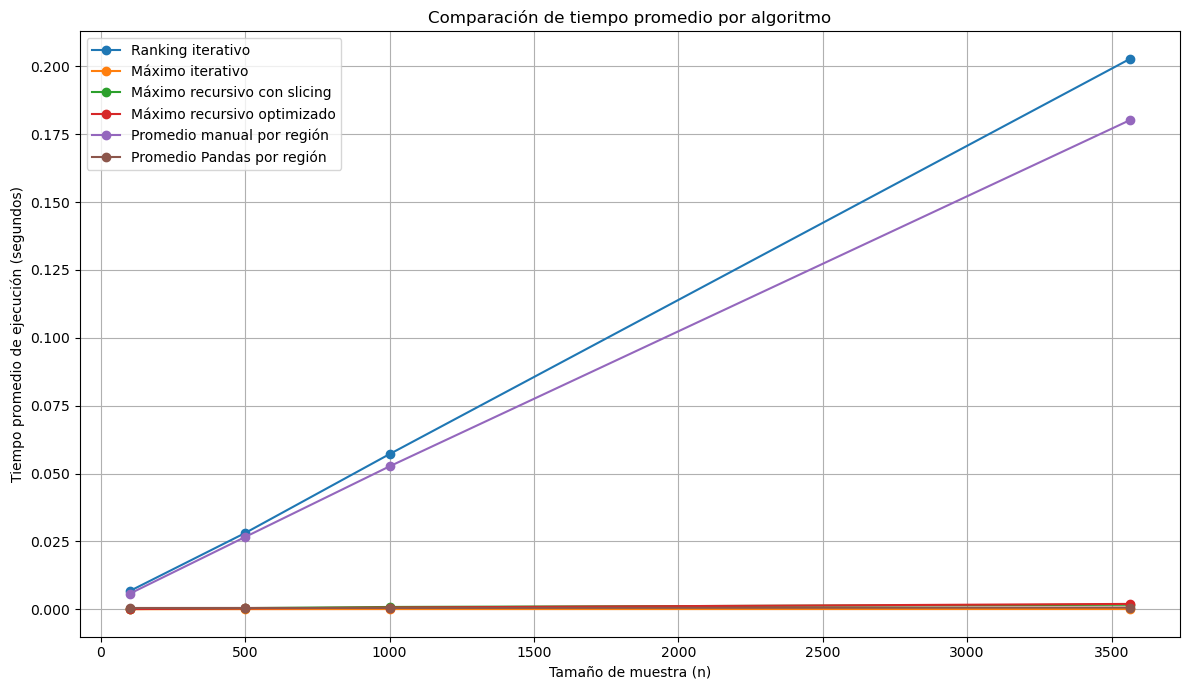

Gráfico de tiempo guardado en: C:\Users\warevalo\Documents\GitHub\gym-fitness-analytics\reports\fase3\figures\grafico_tiempo_algoritmos.png


In [28]:
plt.figure(figsize=(12, 7))

for algoritmo in df_mediciones["algoritmo"].unique():
    datos_algoritmo = df_mediciones[df_mediciones["algoritmo"] == algoritmo]

    plt.plot(
        datos_algoritmo["n"],
        datos_algoritmo["tiempo_promedio_seg"],
        marker="o",
        label=algoritmo
    )

plt.xlabel("Tamaño de muestra (n)")
plt.ylabel("Tiempo promedio de ejecución (segundos)")
plt.title("Comparación de tiempo promedio por algoritmo")
plt.legend()
plt.grid(True)
plt.tight_layout()

ruta_tiempo = FIGURES_DIR / "grafico_tiempo_algoritmos.png"
plt.savefig(ruta_tiempo, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico de tiempo guardado en:", ruta_tiempo)

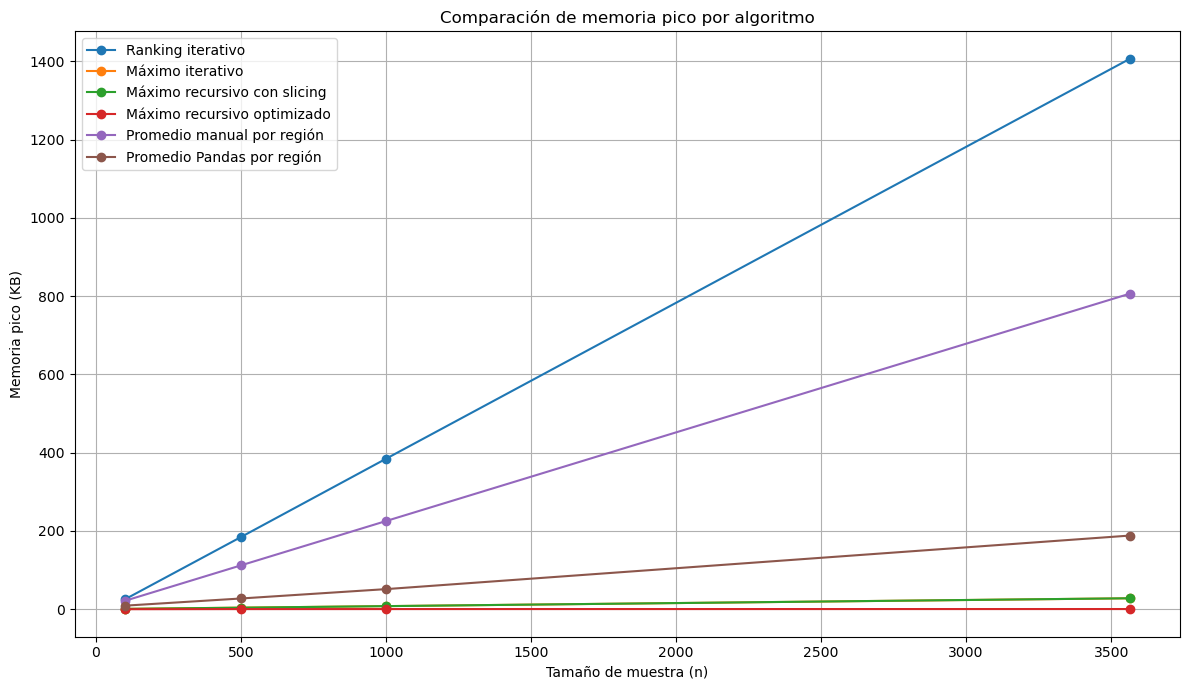

Gráfico de memoria guardado en: C:\Users\warevalo\Documents\GitHub\gym-fitness-analytics\reports\fase3\figures\grafico_memoria_algoritmos.png


In [29]:
plt.figure(figsize=(12, 7))

for algoritmo in df_mediciones["algoritmo"].unique():
    datos_algoritmo = df_mediciones[df_mediciones["algoritmo"] == algoritmo]

    plt.plot(
        datos_algoritmo["n"],
        datos_algoritmo["memoria_pico_kb"],
        marker="o",
        label=algoritmo
    )

plt.xlabel("Tamaño de muestra (n)")
plt.ylabel("Memoria pico (KB)")
plt.title("Comparación de memoria pico por algoritmo")
plt.legend()
plt.grid(True)
plt.tight_layout()

ruta_memoria = FIGURES_DIR / "grafico_memoria_algoritmos.png"
plt.savefig(ruta_memoria, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico de memoria guardado en:", ruta_memoria)

## 6. Decisión algorítmica

Cierra la comparación y justifica la elección final de implementación por problema.

In [30]:
df_decision_algoritmica = pd.DataFrame([
    {
        "problema": "Búsqueda de máximo",
        "implementacion_elegida": "Máximo iterativo",
        "motivo": "Menor uso de memoria y mayor simplicidad",
        "complejidad_temporal": "O(n)",
        "complejidad_espacial": "O(1)"
    },
    {
        "problema": "Búsqueda de máximo con enfoque recursivo",
        "implementacion_elegida": "Máximo recursivo optimizado",
        "motivo": "Mantiene divide and conquer evitando copias por slicing",
        "complejidad_temporal": "O(n)",
        "complejidad_espacial": "O(log n)"
    },
    {
        "problema": "Ranking de países",
        "implementacion_elegida": "Ranking iterativo con sorted",
        "motivo": "Permite ordenar todos los registros y obtener top_n",
        "complejidad_temporal": "O(n log n)",
        "complejidad_espacial": "O(n)"
    },
    {
        "problema": "Promedio por región",
        "implementacion_elegida": "Pandas groupby",
        "motivo": "Mayor legibilidad y rendimiento práctico en datos tabulares",
        "complejidad_temporal": "O(n) aprox.",
        "complejidad_espacial": "O(k)"
    }
])

df_decision_algoritmica

,problema,implementacion_elegida,motivo,complejidad_temporal,complejidad_espacial
0,Búsqueda de máximo,Máximo iterativo,Menor uso de memoria y mayor simplicidad,O(n),O(1)
1,Búsqueda de máximo con enfoque recursivo,Máximo recursivo optimizado,Mantiene divide and conquer evitando copias po...,O(n),O(log n)
2,Ranking de países,Ranking iterativo con sorted,Permite ordenar todos los registros y obtener ...,O(n log n),O(n)
3,Promedio por región,Pandas groupby,Mayor legibilidad y rendimiento práctico en da...,O(n) aprox.,O(k)


## Conclusión

Este notebook evidencia mediciones reproducibles, comparación de implementaciones y justificación de elección algorítmica considerando complejidad temporal y espacial.

## Verificación de figuras generadas

Lista los archivos `.png` guardados en `reports/fase3/figures/`.


In [31]:
archivos_generados = list(FIGURES_DIR.glob("*.png"))

print("Figuras generadas en F3:")

for archivo in archivos_generados:
    print("-", archivo.name)

if not archivos_generados:
    print("No se encontraron figuras. Verifica que las celdas de gráficos se hayan ejecutado después de crear df_mediciones.")

Figuras generadas en F3:
- grafico_memoria_algoritmos.png
- grafico_tiempo_algoritmos.png
